### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import pandas as pd
#plt.style.use("dark_background")

In [8]:
font = {'size'   : 10}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
matplotlib.rcParams['figure.dpi'] = 300

In [9]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image
import pydotplus

from sklearn.tree import export_graphviz

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [10]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [11]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [12]:
# Tamaño del dataset
LearningSet.shape
print(LearningSet.shape)

(18, 5)


In [13]:
LearningSet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_NAME       18 non-null     object 
 1   S_MASS       18 non-null     float64
 2   P_PERIOD     18 non-null     float64
 3   P_DISTANCE   18 non-null     float64
 4   P_HABITABLE  18 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 864.0+ bytes


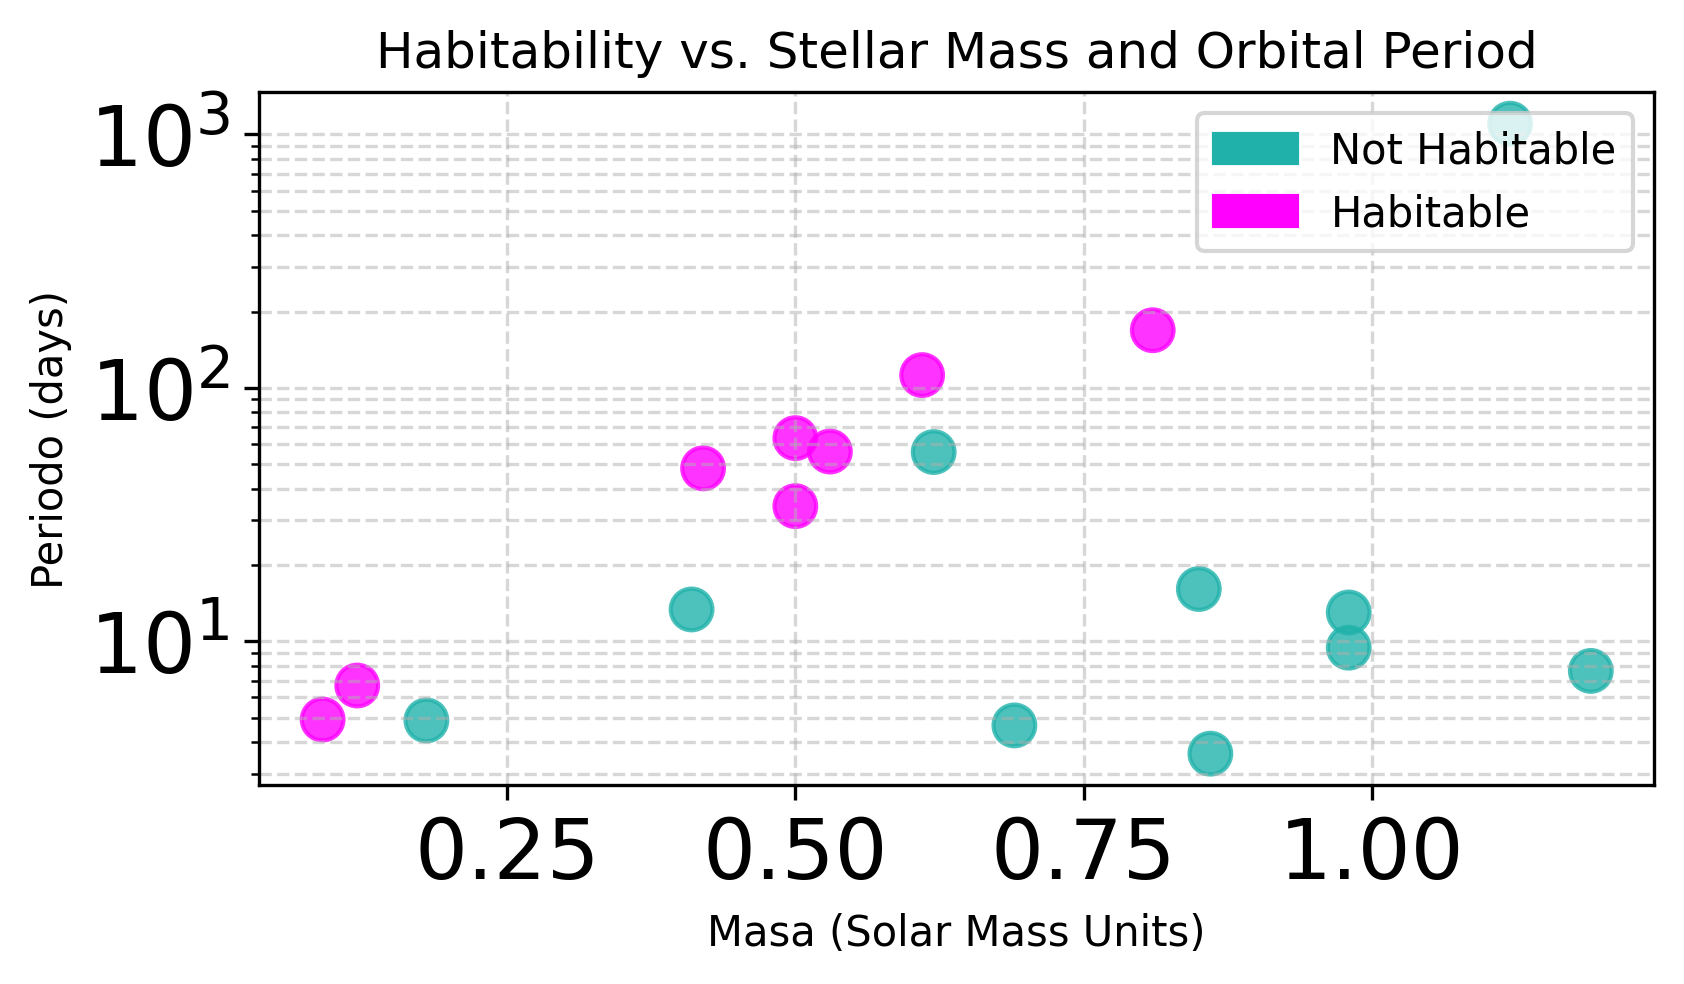

In [14]:
plt.figure(figsize=(6, 3))

# Define colors for habitable and non-habitable planets
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.scatter(LearningSet['S_MASS'], LearningSet['P_PERIOD'],
            c=LearningSet['P_HABITABLE'], cmap=cmap, s=100, alpha=0.8)

plt.yscale('log') # Set y-axis to log scale

plt.xlabel('Masa (Solar Mass Units)')
plt.ylabel('Periodo (days)')
plt.title('Habitability vs. Stellar Mass and Orbital Period')

# Create a custom legend for habitability
bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
plt.legend(handles=[bluepatch, magentapatch], loc='upper right')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


A priori no se separan facilmente de forma lineal, ya que los datos están muy juntos entre sí, por lo que requiere un modelo capaz de encontrar fronteras más complejas.

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [15]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [16]:
TrainSet =  LearningSet.iloc[:13,:]

TestSet = LearningSet.iloc[13:,:]

In [17]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [18]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [19]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [20]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [21]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [22]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [23]:
ytrain

,P_HABITABLE
0,0
1,0
2,0
3,1
4,0
5,1
6,0
7,1
8,0
9,1


### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [24]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [25]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/)

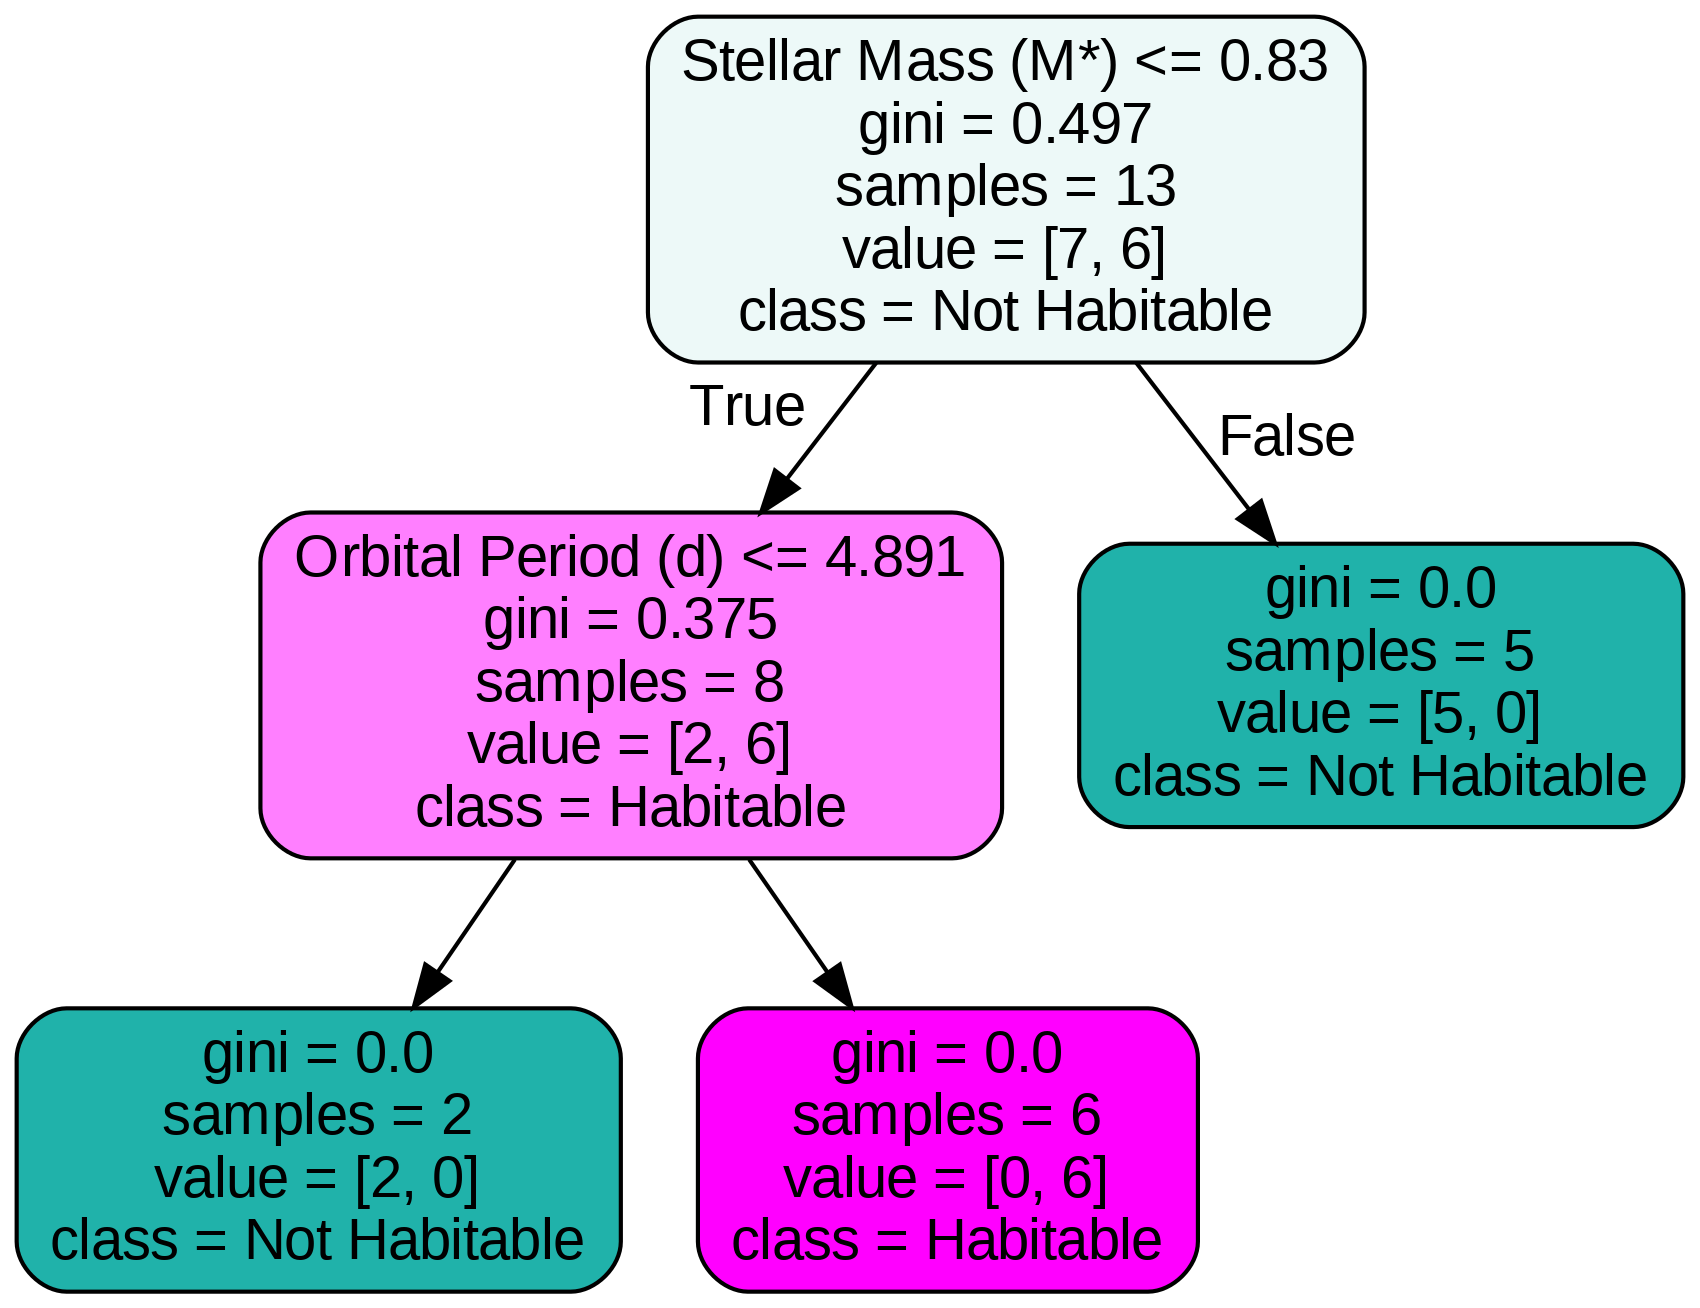

In [26]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

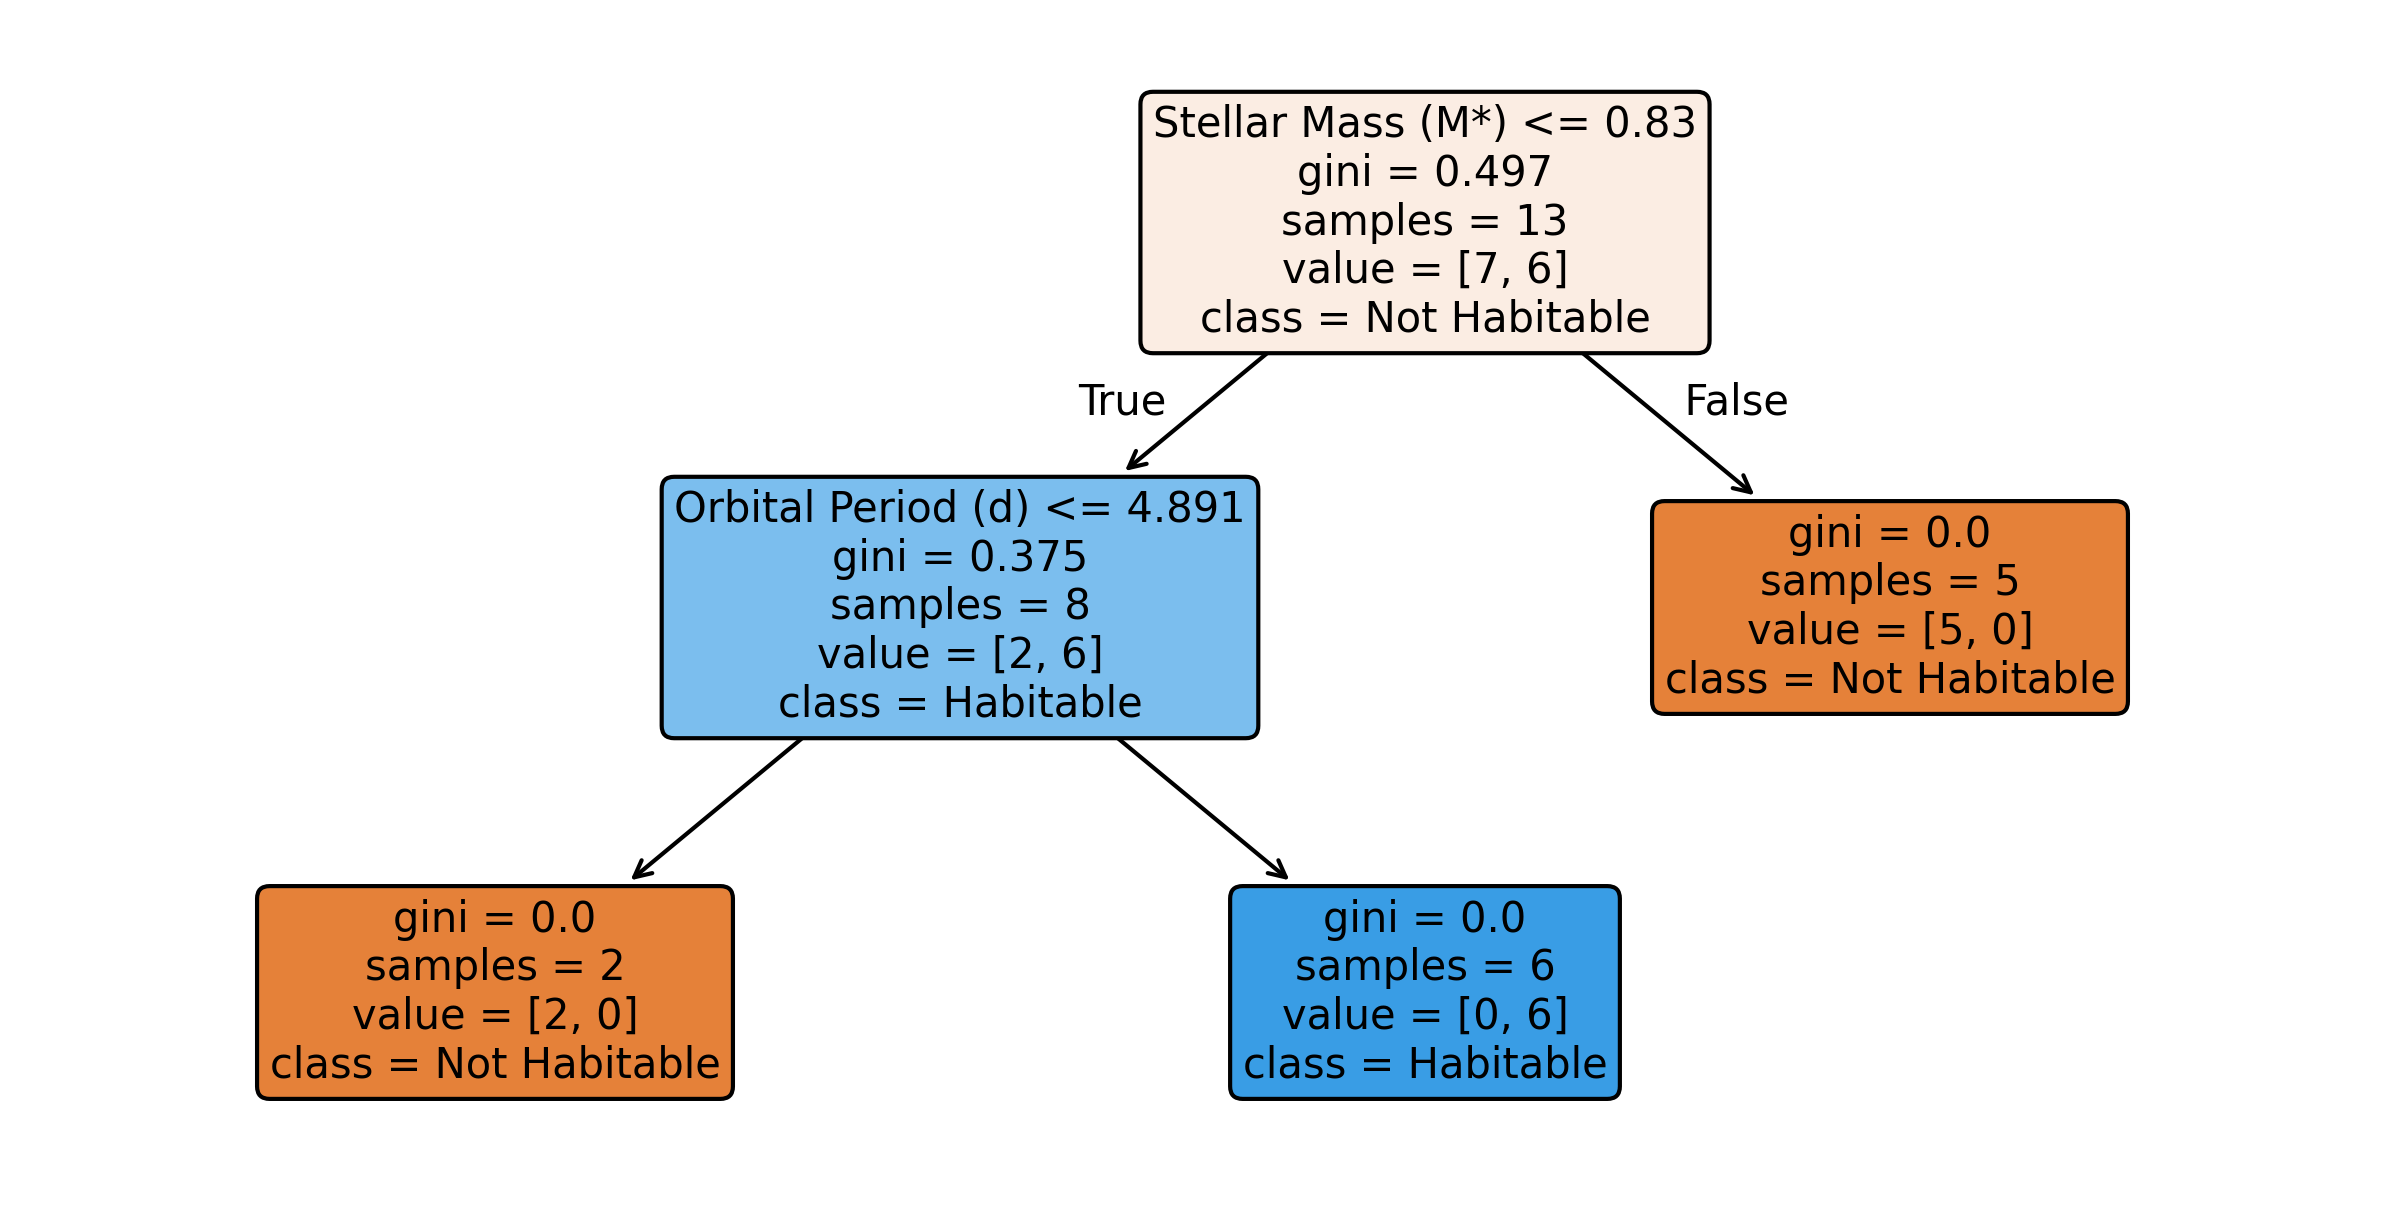

In [27]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

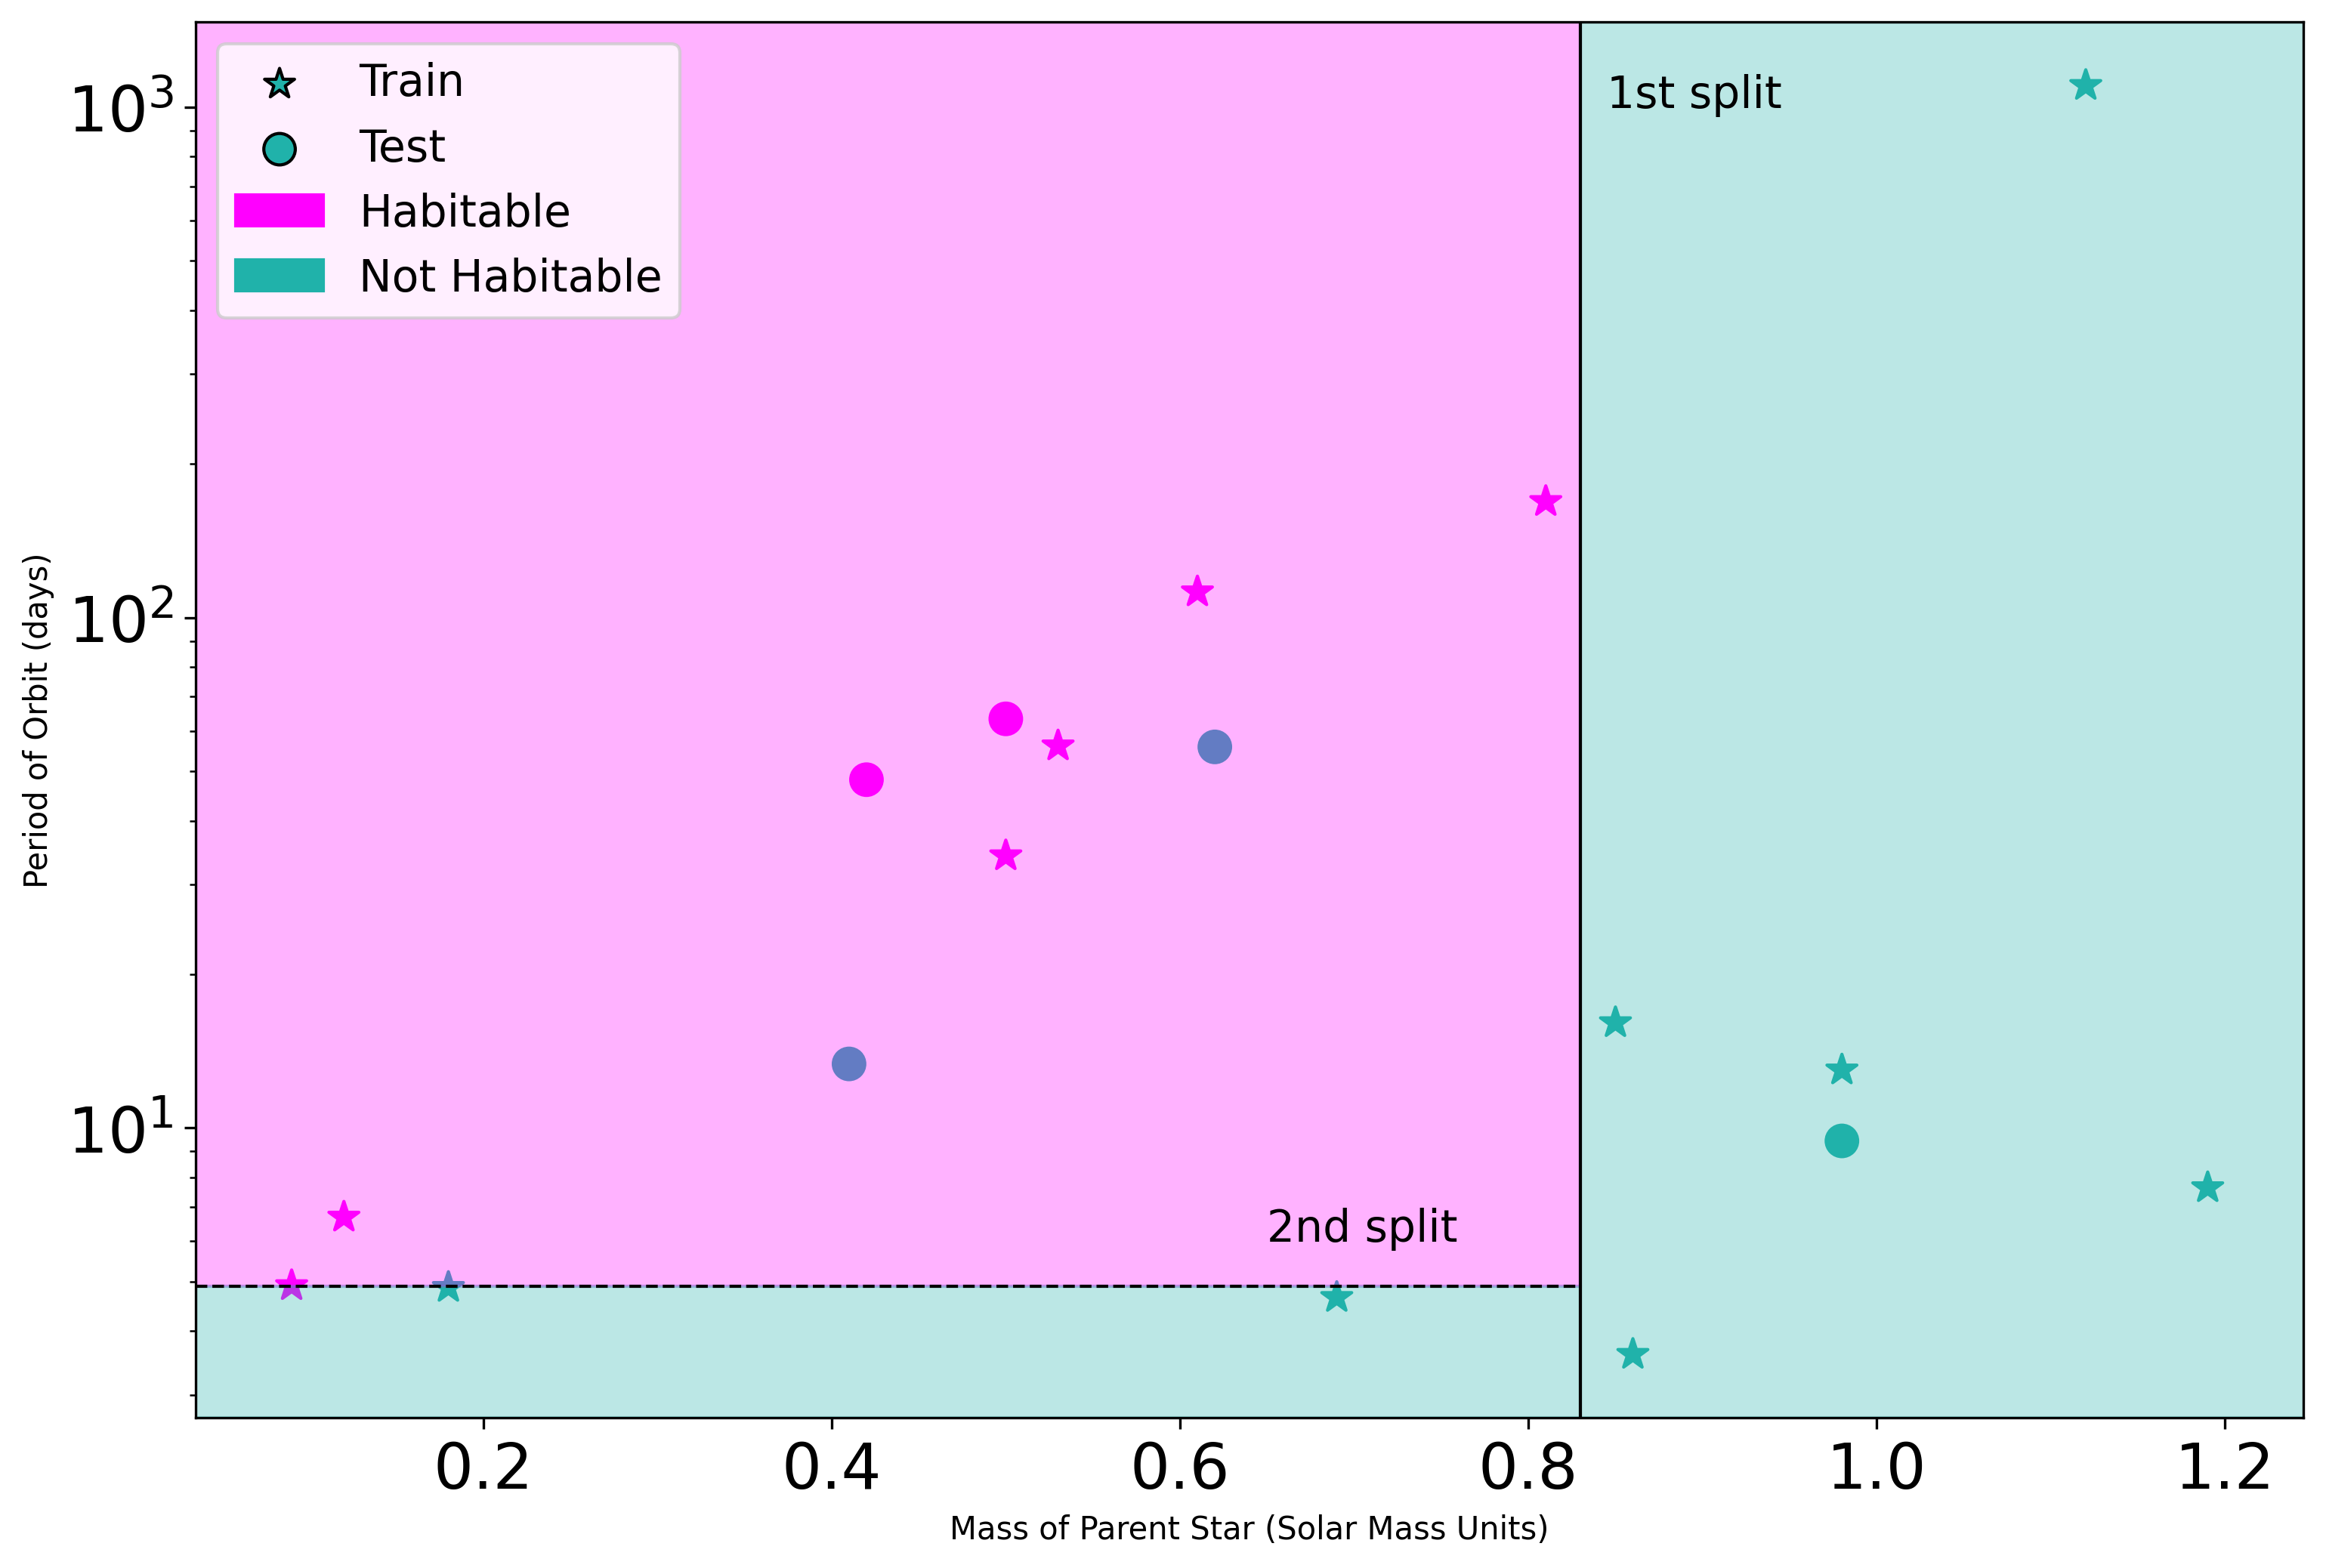

In [28]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

In [29]:
dt_model = DecisionTreeClassifier(random_state=3)
dt_model.fit(Xtrain, ytrain)

# Accuracy en el set de entrenamiento
train_accuracy = metrics.accuracy_score(ytrain, dt_model.predict(Xtrain))
print(f"Accuracy en entrenamiento (Decision Tree): {train_accuracy}")

# Accuracy en el set de prueba
ypred_dt = dt_model.predict(Xtest)
test_accuracy = metrics.accuracy_score(ytest, ypred_dt)
print(f"Accuracy en prueba (Decision Tree): {test_accuracy}")

Accuracy en entrenamiento (Decision Tree): 1.0
Accuracy en prueba (Decision Tree): 0.6


### usando la métricas de sklearn, podemos encontrar el accuracy


In [30]:
import sklearn.metrics as metrics


In [31]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [32]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [33]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [34]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
2. ¿Qué ocurre en el conjunto de prueba?
3. ¿Qué variable aparece en la raíz del árbol?
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?


1. Sí, El modelo alcanza un accuracy de 1.0 en el set de entrenamiento.

2. El desempeño baja a un 83.3%. Esto indica que el modelo no es perfecto generalizando con datos nuevos y que existe un ligero sobreajuste.

3. La stellar mass.

4. Para ser un dataset con 18 registros, el árbol igual es relativamente profundo.

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [35]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:]

TestSet2 = LearningSet.iloc[:5,:]

Xtrain2= TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1)

Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)

ytrain2= TrainSet2.P_HABITABLE

ytest2 = TestSet2.P_HABITABLE

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [36]:
model2 = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model2.fit(Xtrain2, ytrain2) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

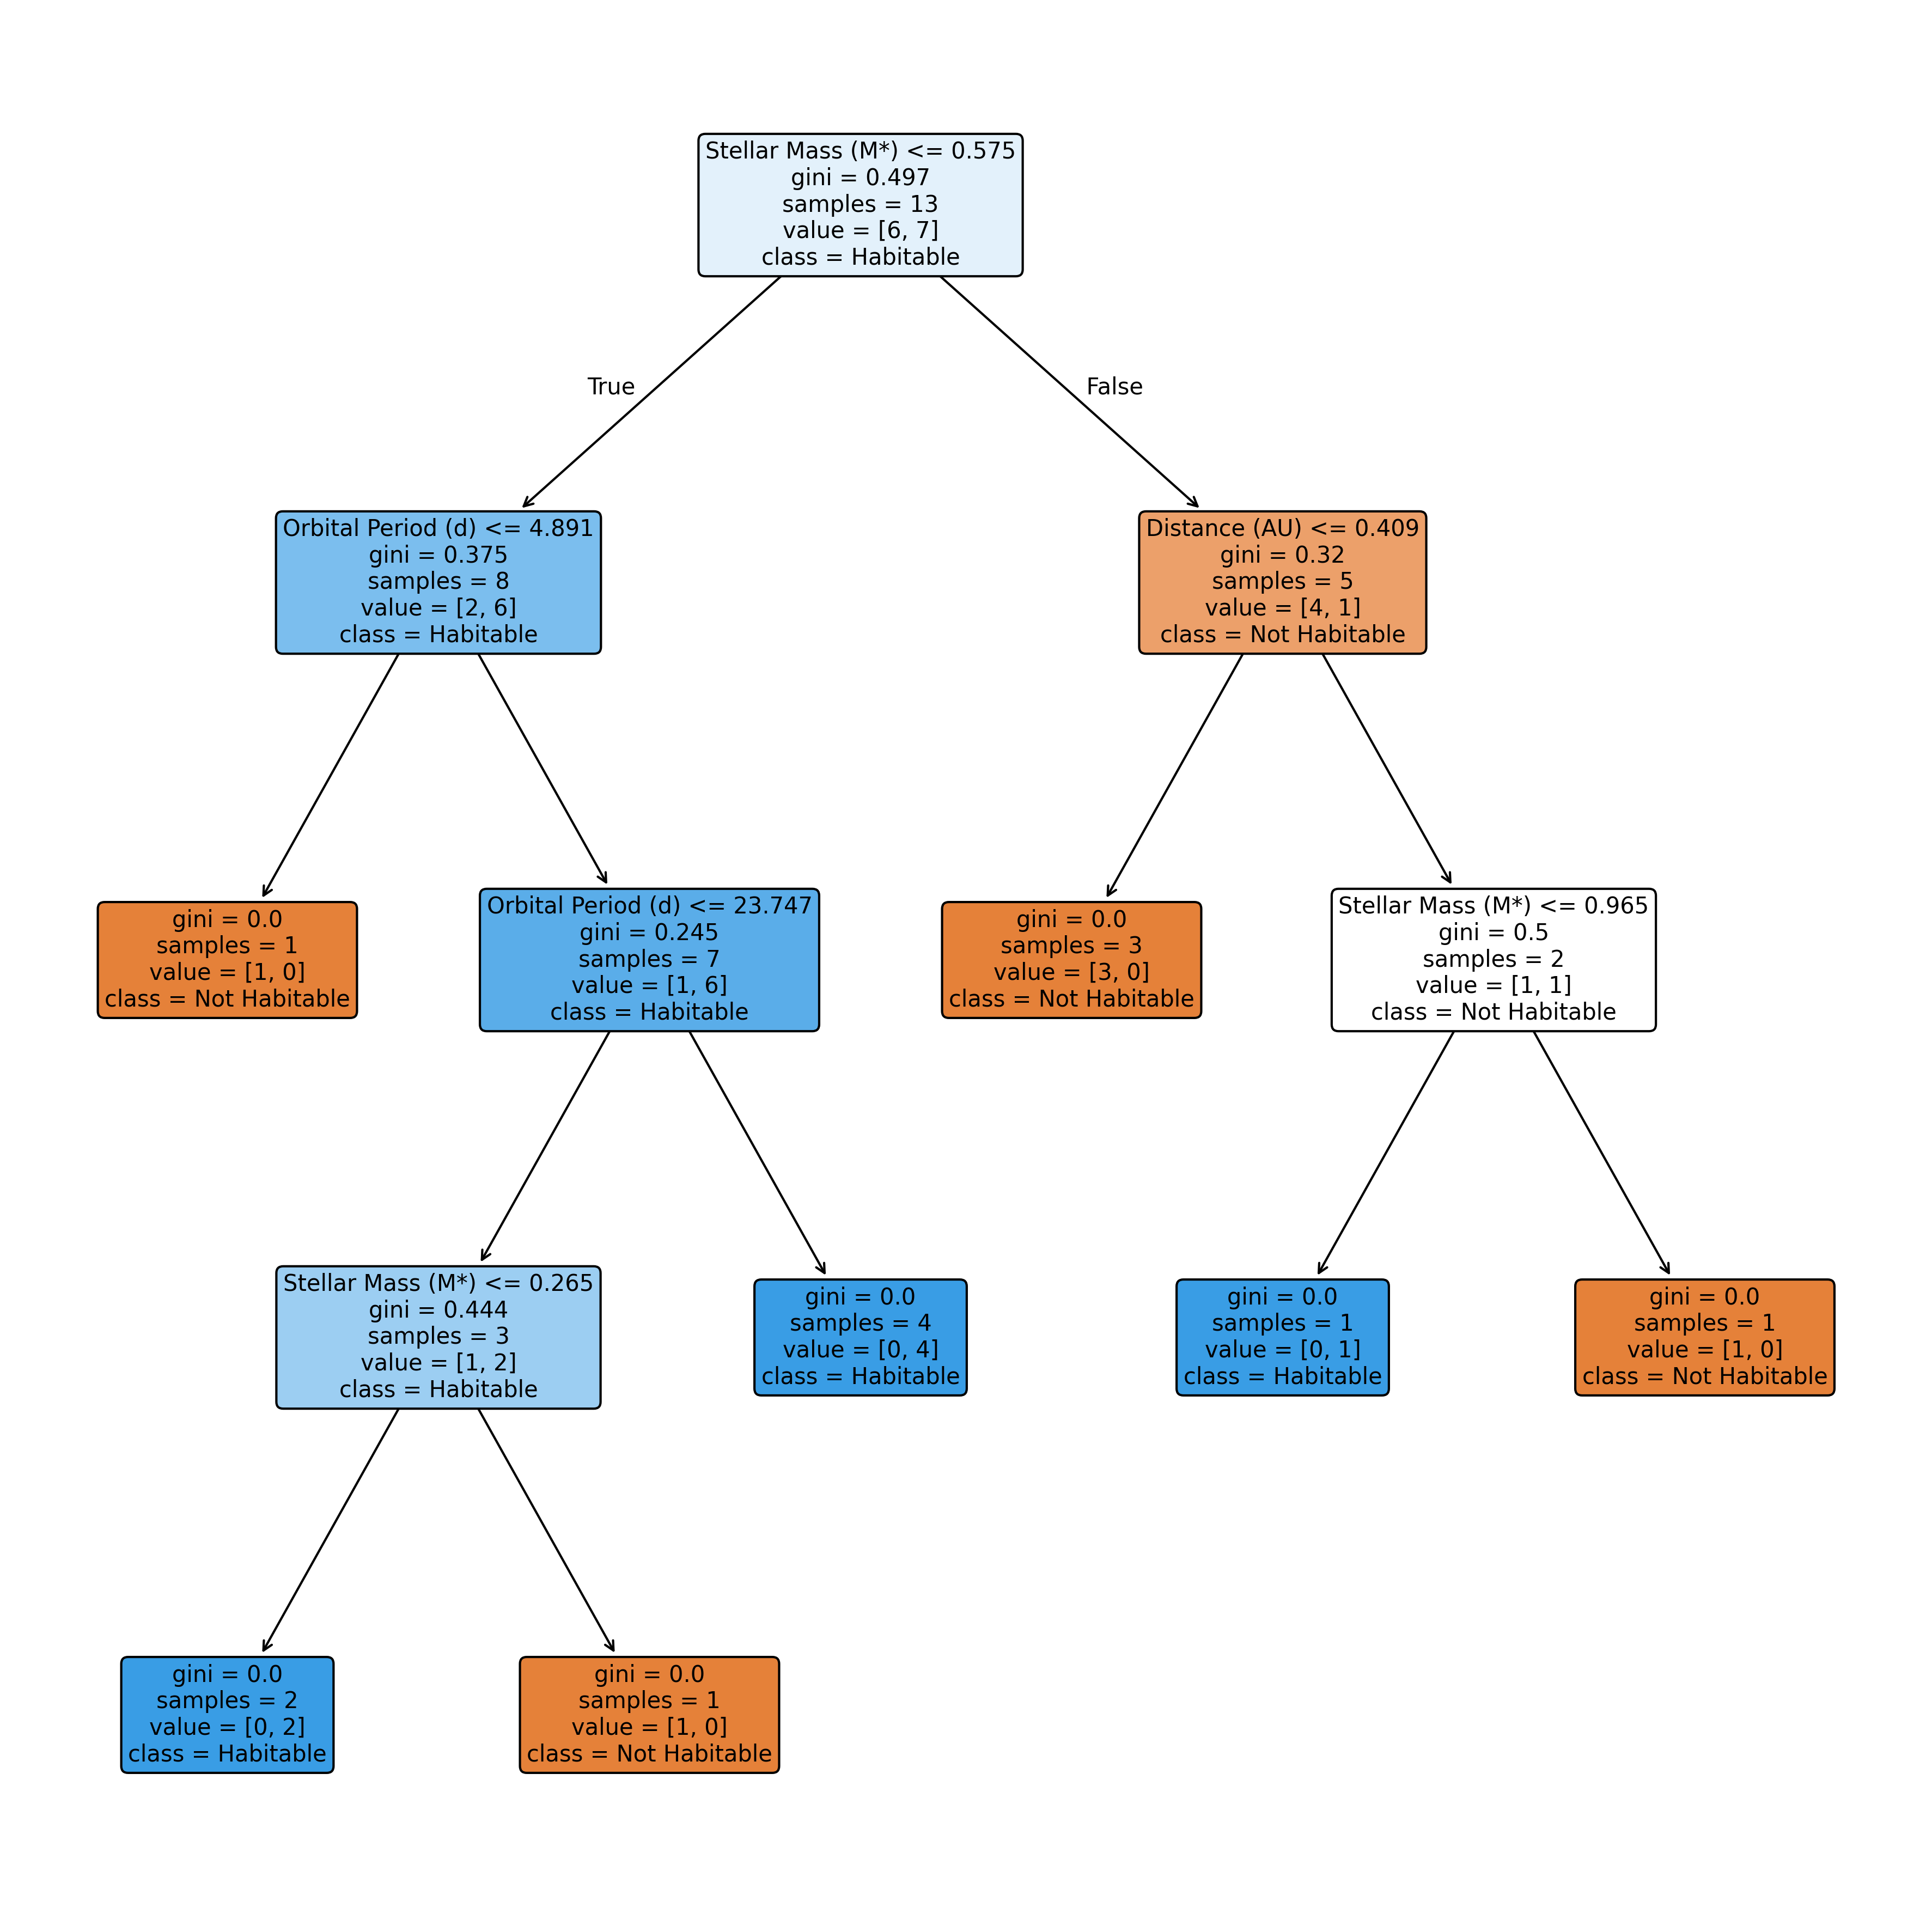

In [37]:
plt.figure(figsize=(15,15))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

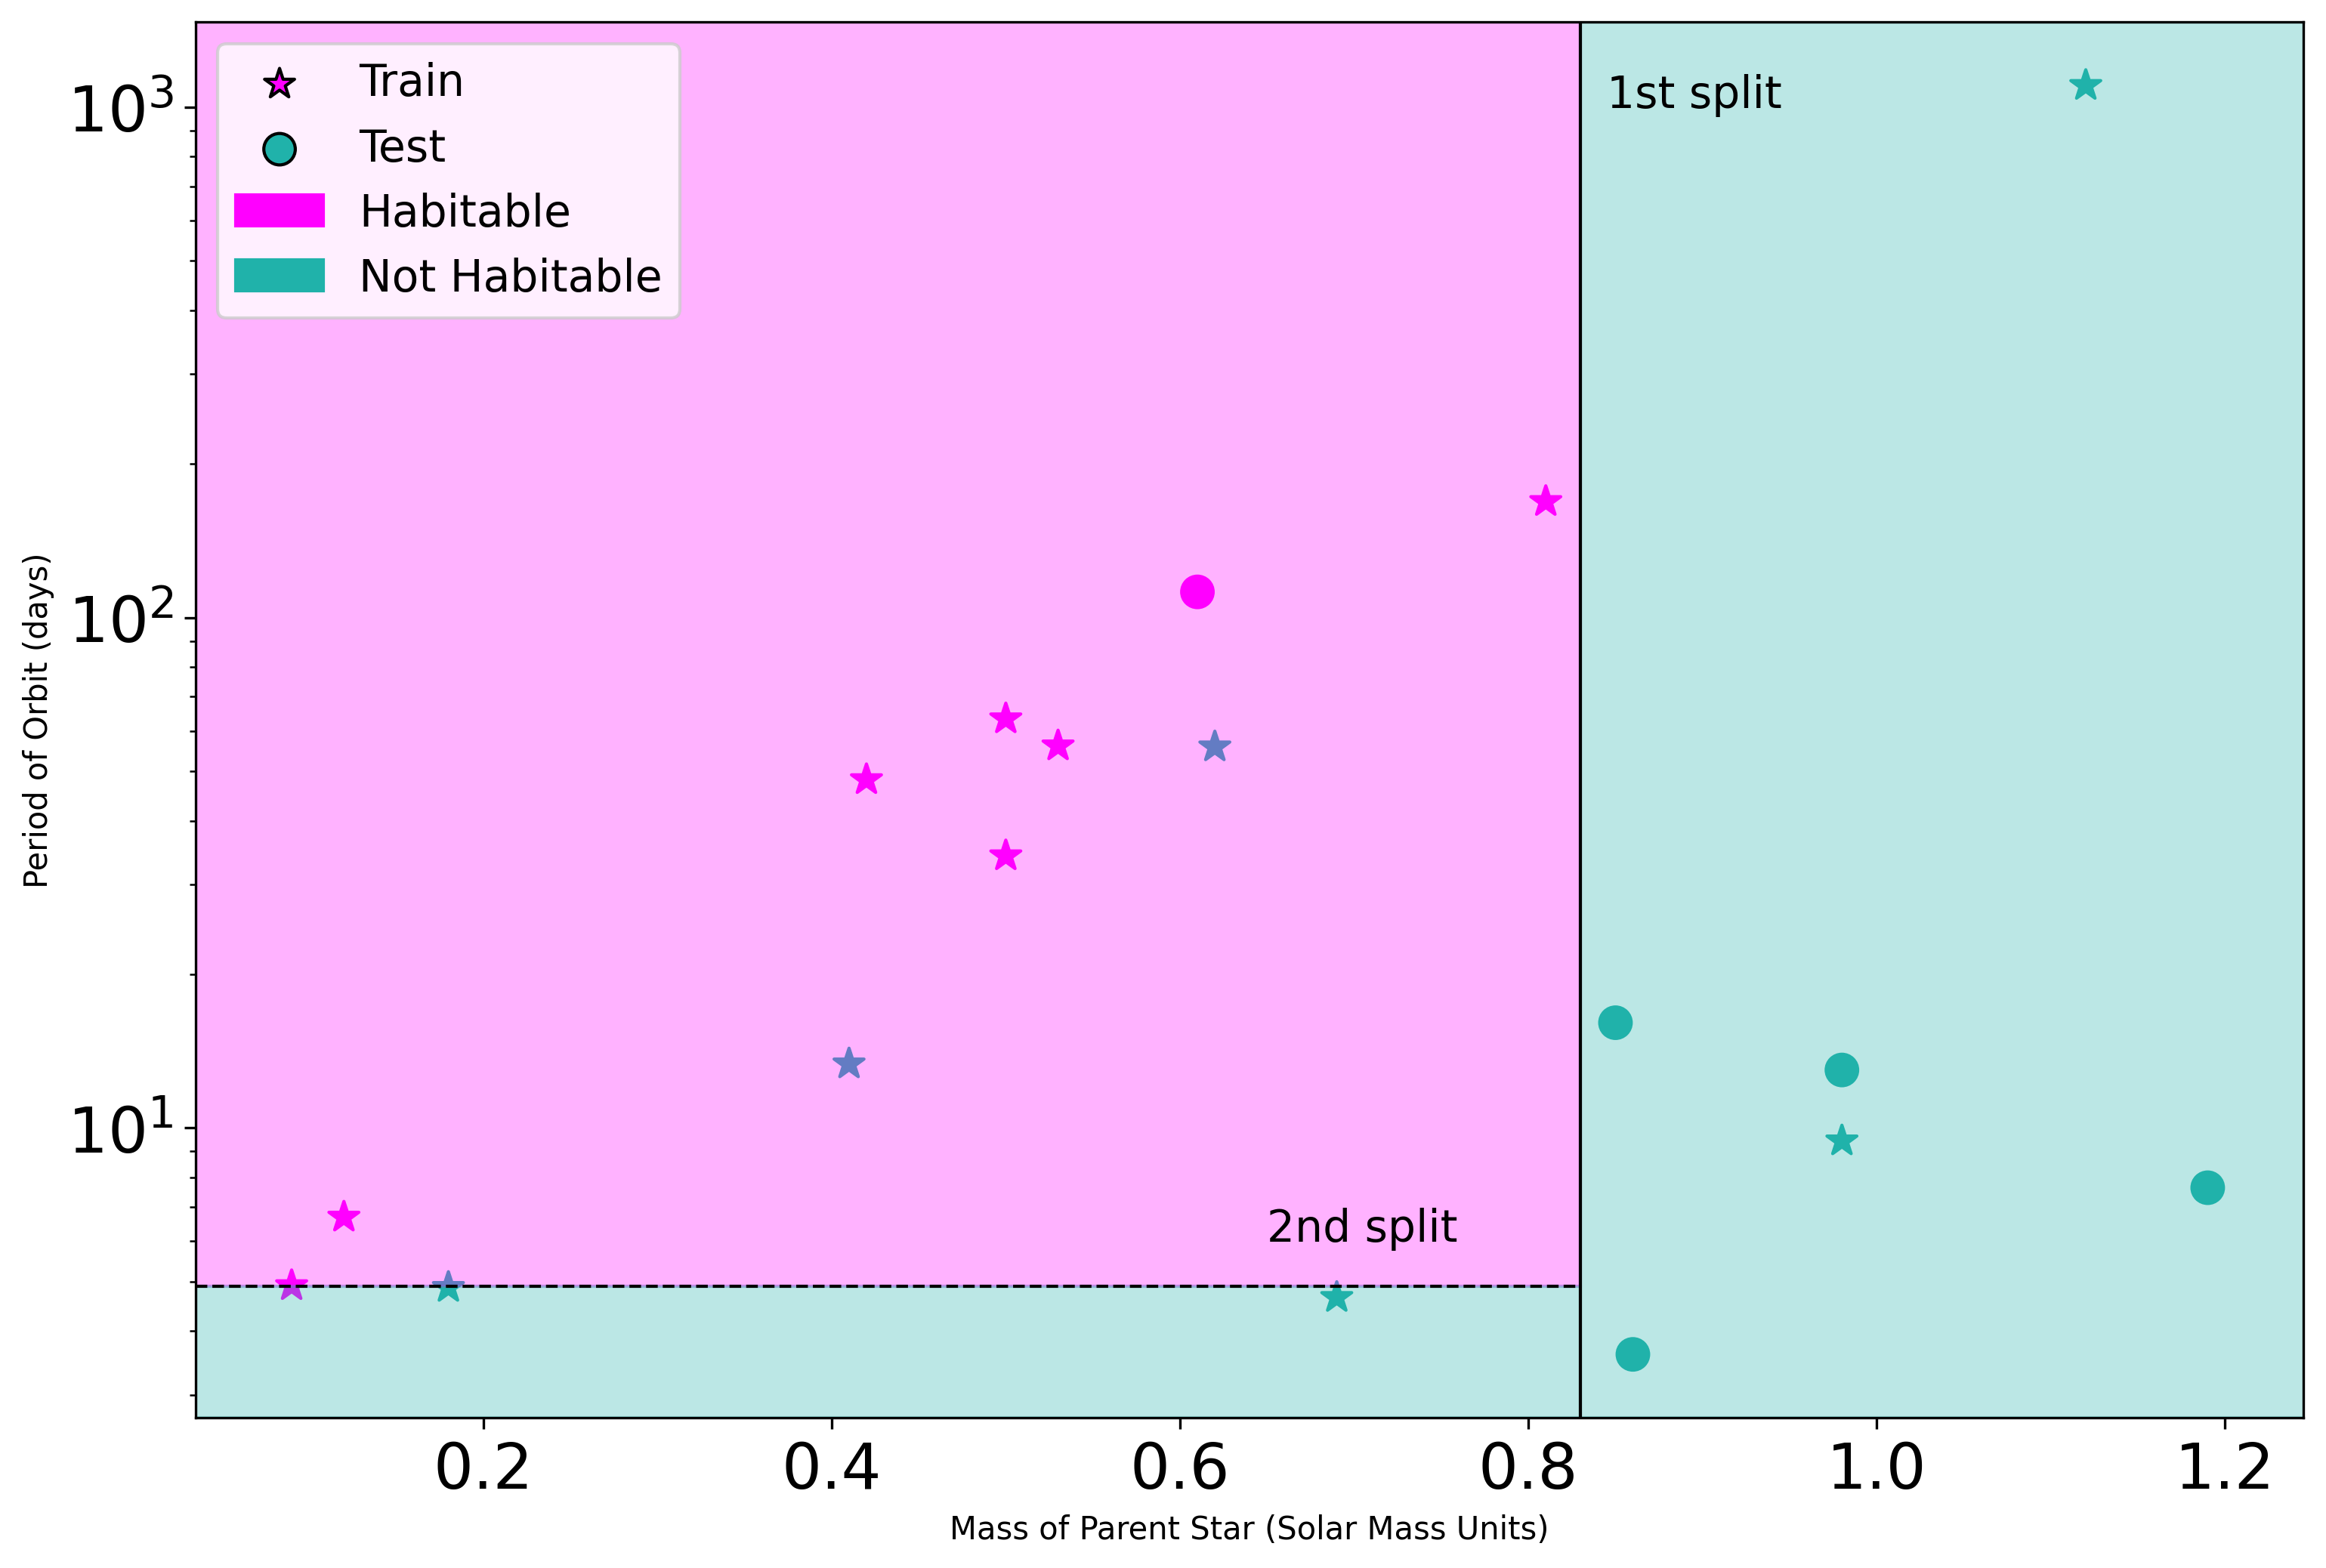

In [38]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet2['S_MASS'], TrainSet2['P_PERIOD'], marker = '*',\
            c = TrainSet2['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet2['S_MASS'], TestSet2['P_PERIOD'], marker = 'o',\
            c = TestSet2['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

La diferencia está en los valores de corte.

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento?

El accuracy es 1.

- ¿Y en el conjunto de prueba?

1 también.

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?

A priori sí, ya que logra una mejor clasificación


### Conclusiones

- Que puede concluir respecto a al ejercicio?

Que cambiando los parámetros, tanto de test como entrenamiento puede ser util para simplificar los árboles de decisiones.

- Cambian los resultados dependiendo del set de datos que utilizamos?

Los resultados como tal no cambia, sí los de entremamiento y prueba.

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

No entra dentro del rango de habitabilidad, dada la masa estelar.

## k-Nearest Neighbors

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [39]:
from sklearn import neighbors
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [40]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [41]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [42]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [43]:
Xtrain.iloc[:,:2]

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [44]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [45]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [46]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [47]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [48]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles

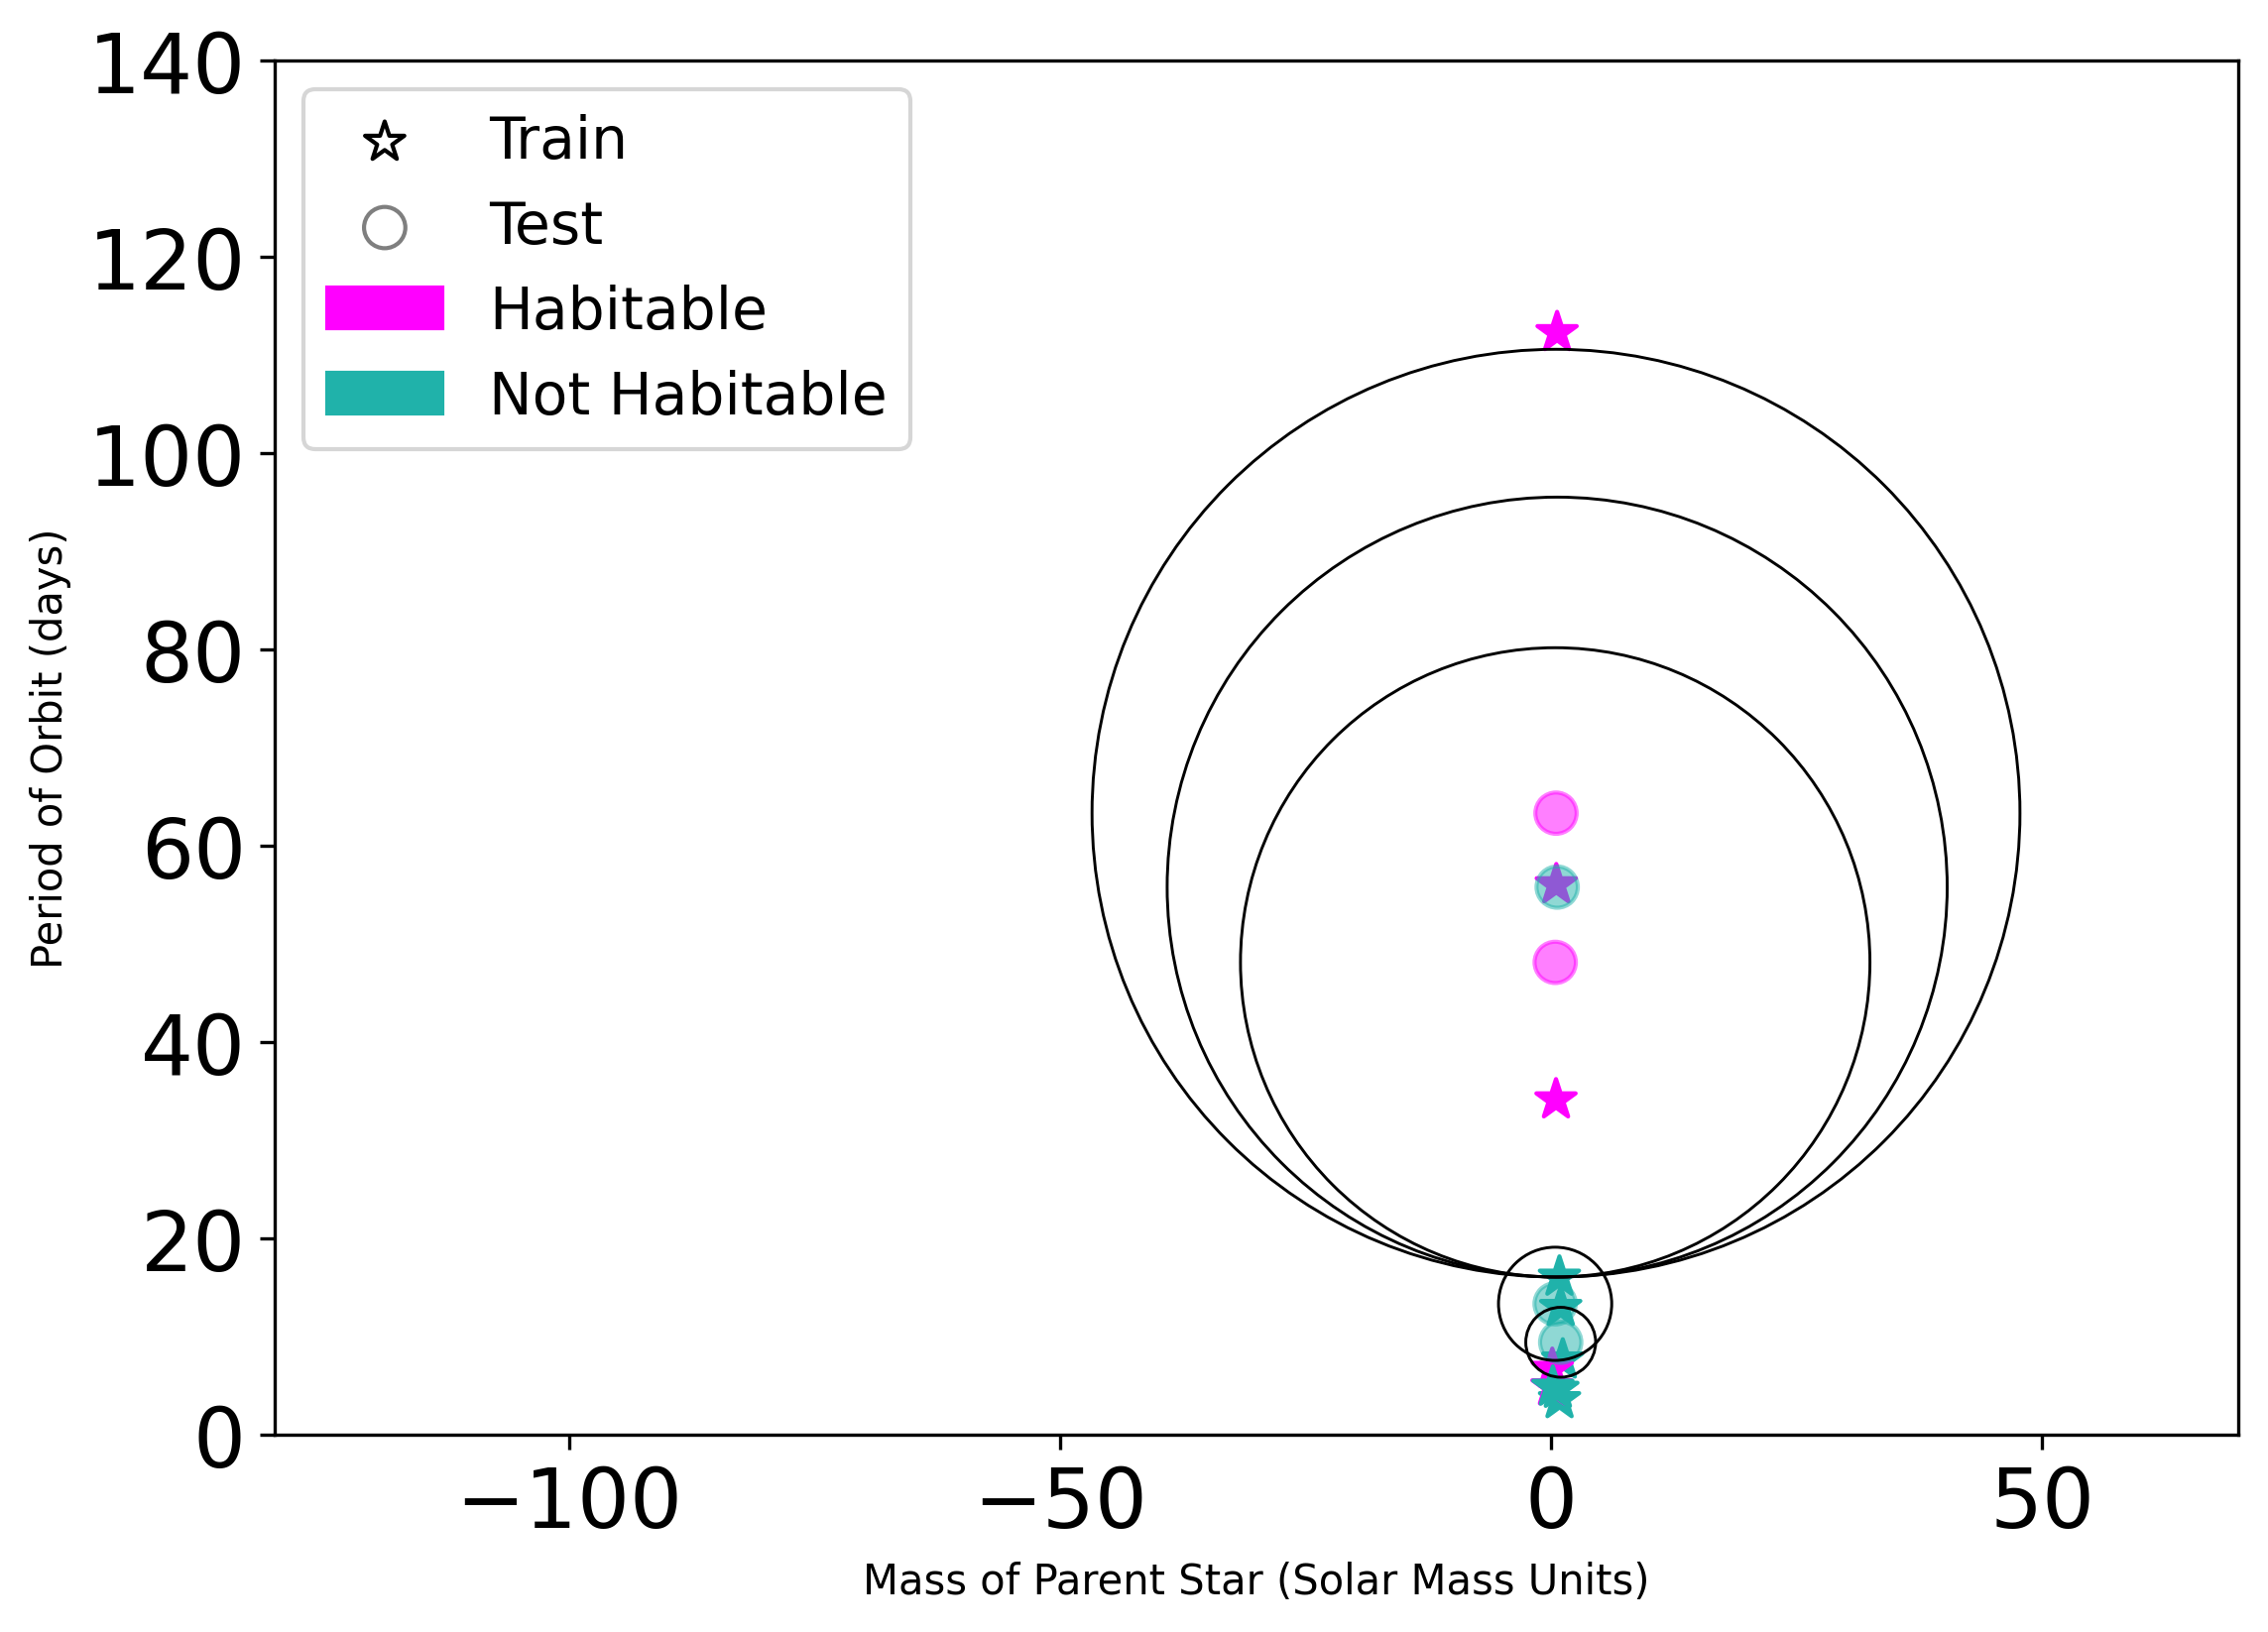

In [49]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [97]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [98]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [99]:
scaledXTrain = scaler.transform(Xtrain)

In [100]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [101]:
scaledXtest = scaler.transform(Xtest) #

In [102]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [103]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [104]:
model.fit(scaledXtest,ytest) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(scaledXtest) #esto ajsta el modelo en los datos de prueba

model.fit(scaledXTrain[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(scaledXtest[:,:2]) #esto ajsta el modelo en los datos de prueba

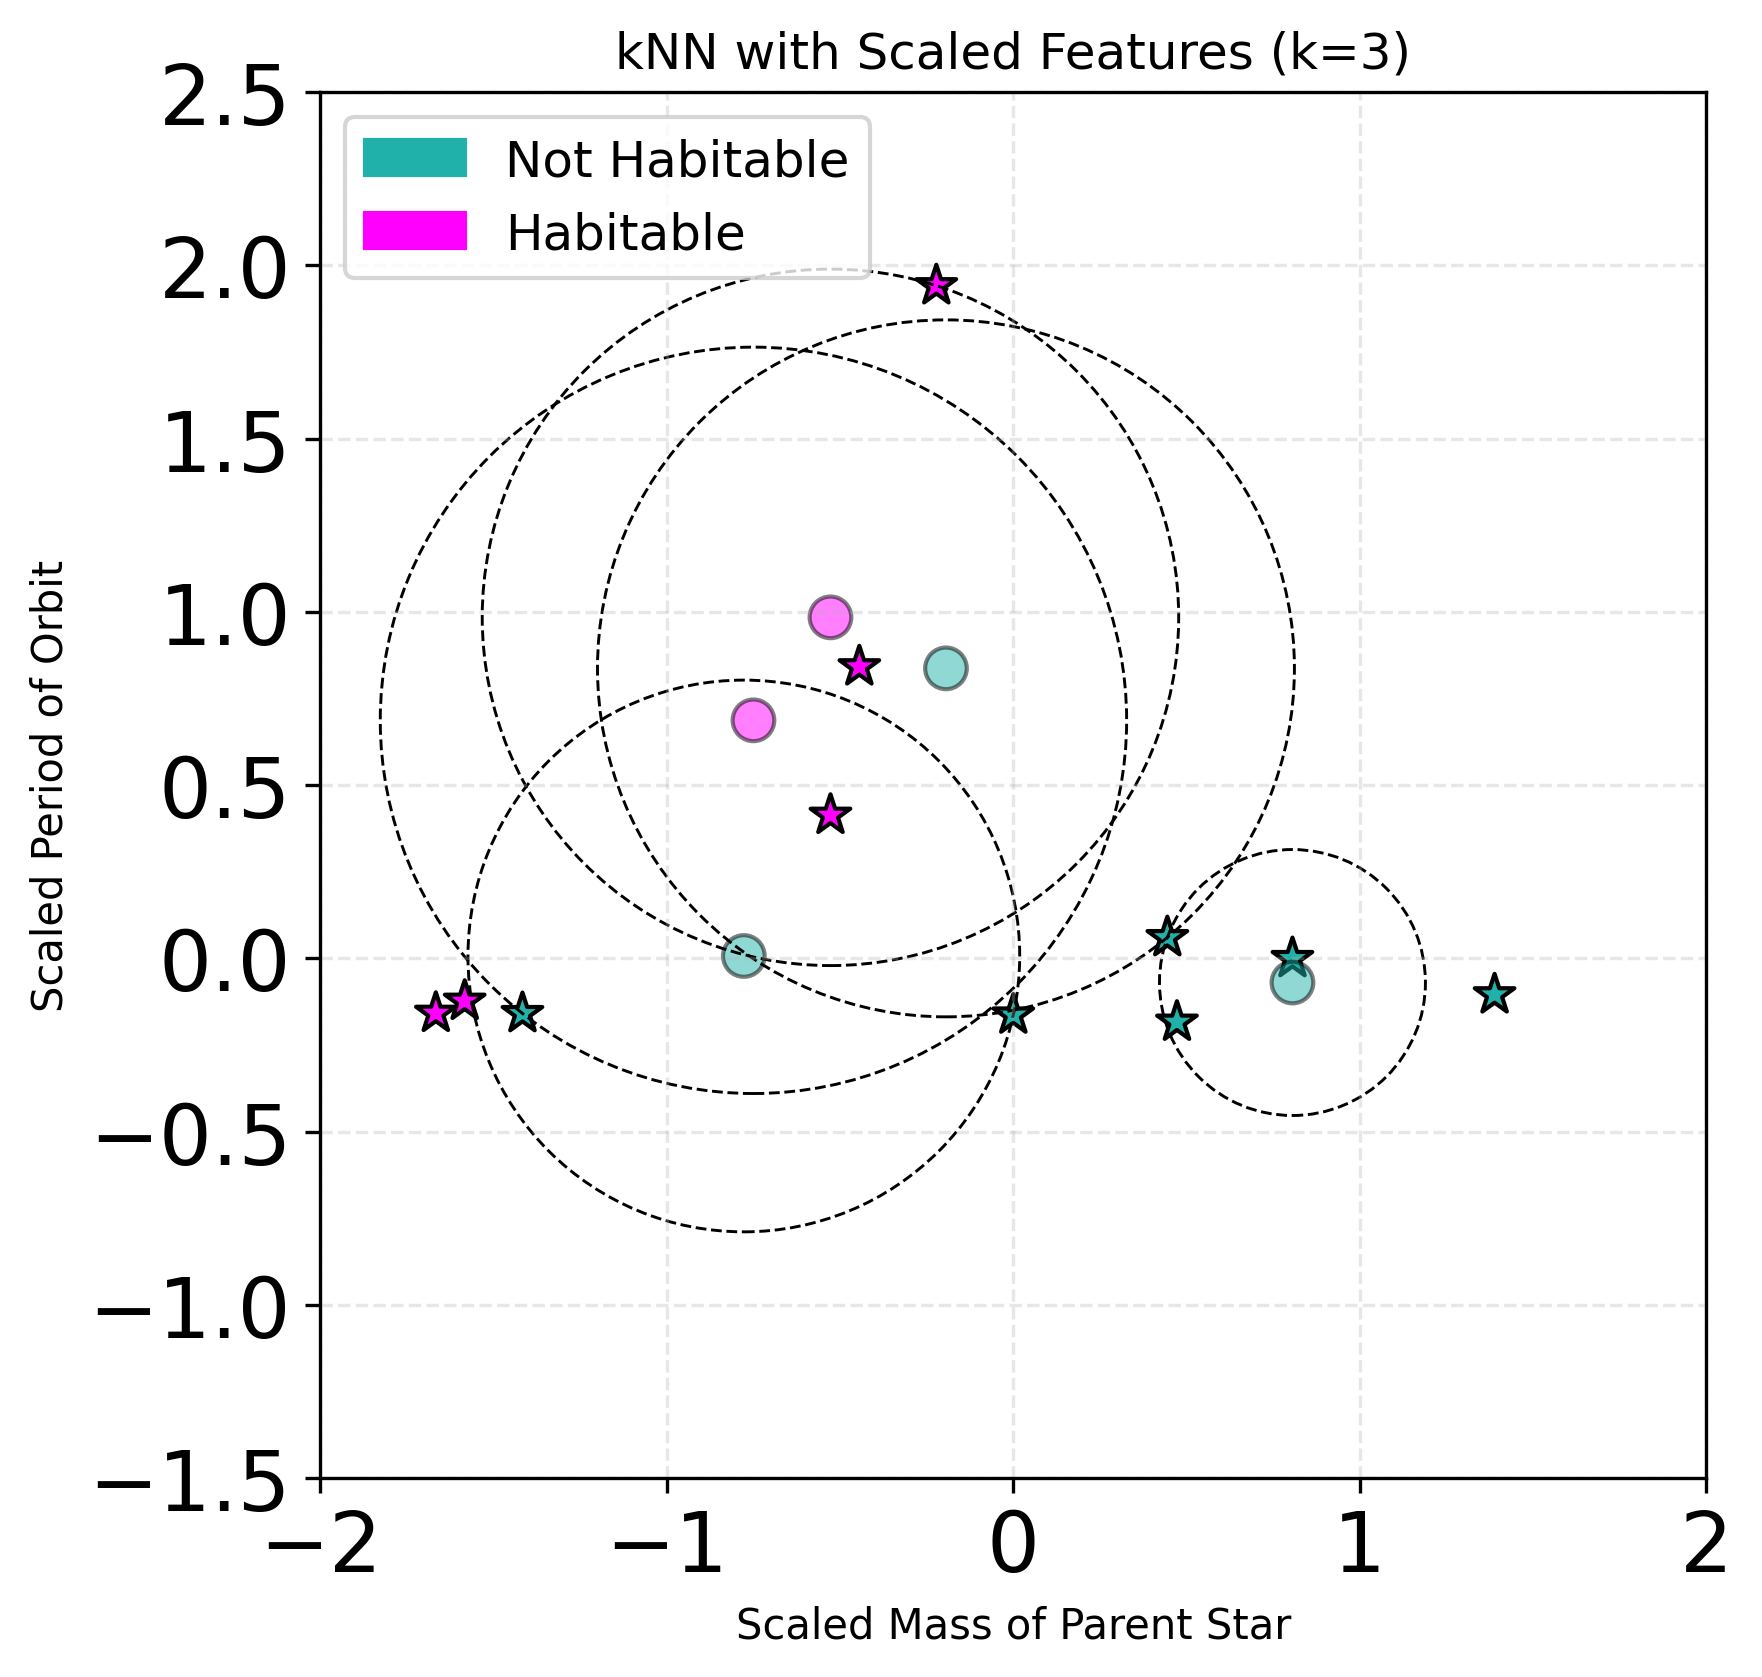

Accuracy (Train Scaled): 0.8461538461538461
Accuracy (Test Scaled): 0.8


In [108]:
# Re-fit the model with the scaled training data (first 2 features for visualization)
model.fit(scaledXTrain[:, :2], ytrain)

plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

# Plot scaled training points
plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker='*',
            c=ytrain, s=100, label='Train', cmap=cmap, edgecolors='k')

# Plot scaled test points
plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker='o',
            c=ytest, s=100, label='Test', cmap=cmap, alpha=0.5, edgecolors='k')

# Calculate and plot neighbor circles
for i in range(len(scaledXtest)):
    # Get distance to the 3rd neighbor for the current test point
    dist, _ = model.kneighbors(scaledXtest[i, :2].reshape(1, -1))
    radius = dist[0, 2]

    circle = plt.Circle((scaledXtest[i, 0], scaledXtest[i, 1]), radius,
                        lw=0.7, edgecolor='k', facecolor='none', linestyle='--')
    plt.gca().add_artist(circle)

plt.gca().set_aspect('equal')

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

# Fix legend handles display
plt.legend(handles=[bluepatch, magentapatch], loc='upper left', fontsize=12)
plt.xlim(-2, 2)
plt.ylim(-1.5, 2.5)

plt.xlabel('Scaled Mass of Parent Star')
plt.ylabel('Scaled Period of Orbit')
plt.title('kNN with Scaled Features (k=3)')
plt.grid(True, ls='--',alpha=0.3)
plt.show()

# Accuracy comparison
print(f"Accuracy (Train Scaled): {metrics.accuracy_score(ytrain, model.predict(scaledXTrain[:, :2]))}")
print(f"Accuracy (Test Scaled): {metrics.accuracy_score(ytest, model.predict(scaledXtest[:, :2]))}")

### Preguntas

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

No, los Árboles de Decisión (DT) no tienen ese problema. A diferencia de kNN, los árboles no calculan distancias entre puntos, sino que realizan particiones del espacio mediante umbrales en cada variable de forma independiente. Por esto, la escala de los valores no afecta la lógica de las divisiones del árbol.

- Compare las fortalezas y debilidades de DT y kNN

Para los DT:

Fortalezas: Muy fácil de interpretar y visualizar, no requiere escalar datos y maneja bien valores atípicos.

Debilidades: Tiende al sobreajuste (overfitting) si el árbol crece mucho y es sensible a cambios pequeños en los datos.

Para los kNN:

Fortalezas: Modelo simple e intuitivo que no asume una forma fija en los datos y se adapta bien a nuevos ejemplos.

Debilidades: Requiere obligatoriamente escalado de variables, es lento con datasets grandes y es muy sensible al ruido.

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

El Árbol de Decisión clasifica mediante una jerarquía de reglas lógicas ("si/no") que dividen el espacio en regiones rectangulares cada vez más pequeñas. En cambio, kNN clasifica por "vecindad": un punto nuevo recibe la clase más frecuente de los $k$ puntos más cercanos a él en el espacio de características.

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

Porque un accuracy alto en entrenamiento puede ser señal de sobreajuste (overfitting), lo que significa que el modelo memorizó los datos en lugar de aprender los patrones subyacentes. Lo que realmente importa es la capacidad de generalización, es decir, qué tan bien funciona el modelo con datos nuevos que nunca ha visto (set de prueba).

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

kNN usa cálculos de distancia (como la euclidiana). Si una variable tiene valores de 0 a 1000 y otra de 0 a 1, la variable con números grandes dominará el cálculo y "anulará" a la otra. El Árbol de Decisión solo compara valores individuales contra un umbral (ej. ¿es la masa > 0.5?), por lo que no le importa la escala de las demás variables.

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

Elegiría el Árbol de Decisión. En un dataset tan pequeño (18 datos), la interpretabilidad es fundamental para entender qué factores determinan la habitabilidad. Además, kNN es muy inestable en muestras pequeñas, ya que un solo dato ruidoso puede cambiar drásticamente la clasificación de sus vecinos.


###1. Estudiar el efecto del valor de K. Elegir distintos valores de k y graficar k vs accuracy

k =  1 Train Accuracy: 1.000 Test Accuracy: 0.600
k =  2 Train Accuracy: 1.000 Test Accuracy: 0.600
k =  3 Train Accuracy: 0.846 Test Accuracy: 0.600
k =  4 Train Accuracy: 0.846 Test Accuracy: 0.800
k =  5 Train Accuracy: 0.846 Test Accuracy: 0.600
k =  6 Train Accuracy: 0.692 Test Accuracy: 0.600
k =  7 Train Accuracy: 0.769 Test Accuracy: 0.600
k =  8 Train Accuracy: 0.615 Test Accuracy: 0.600
k =  9 Train Accuracy: 0.769 Test Accuracy: 0.800
k = 10 Train Accuracy: 0.692 Test Accuracy: 0.800
k = 11 Train Accuracy: 0.846 Test Accuracy: 0.600
Best K : 4  Test Accuracy = 0.800


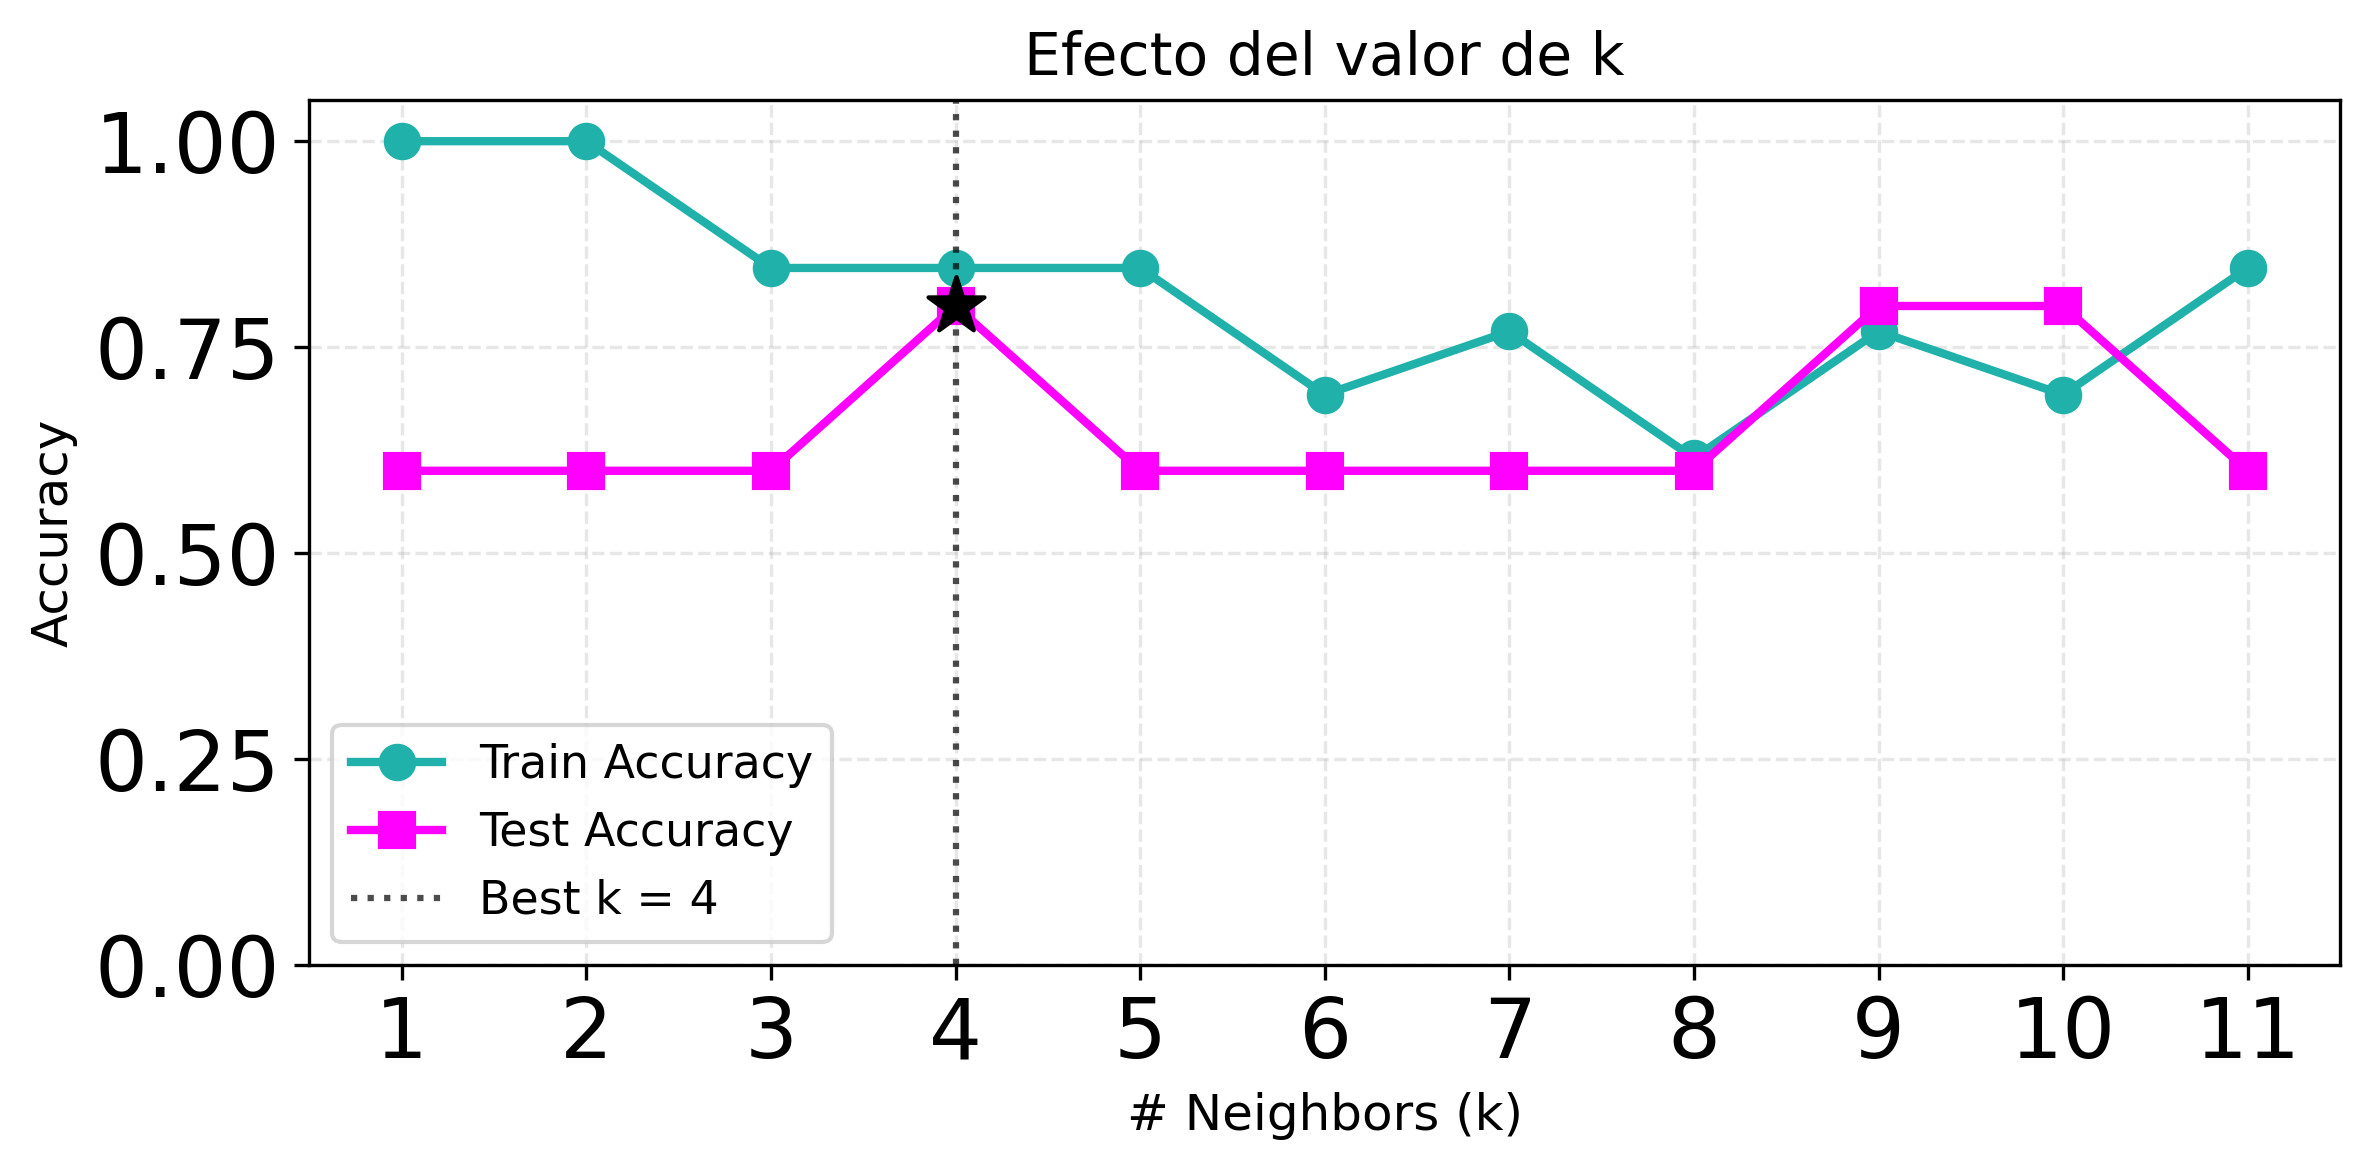

In [95]:
ytrain = TrainSet['P_HABITABLE']
ytest = TestSet['P_HABITABLE']

feature_cols = ['S_MASS', 'P_PERIOD', 'P_DISTANCE']
Xtrain = TrainSet[feature_cols]
Xtest = TestSet[feature_cols]

scaler = StandardScaler()
scaler.fit(Xtrain)
Xtrain_scaled = scaler.transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)


k_values = range(1, min(21, len(Xtrain) - 1))

train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtrain_scaled, ytrain)

    train_pred = knn.predict(Xtrain_scaled)
    test_pred = knn.predict(Xtest_scaled)

    train_acc = metrics.accuracy_score(ytrain, train_pred)
    test_acc = metrics.accuracy_score(ytest, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"k = {k:2d}",
          f"Train Accuracy: {train_acc:.3f}",
          f"Test Accuracy: {test_acc:.3f}")


best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)
print(f"Best K : {best_k}",f" Test Accuracy = {best_accuracy:.3f}")



fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, train_accuracies, 'o-', label='Train Accuracy',
         color='#20B2AA', linewidth=2, markersize=8)
ax.plot(k_values, test_accuracies, 's-', label='Test Accuracy',
         color='#FF00FF', linewidth=2, markersize=8)

ax.axvline(x=best_k, color='black', linestyle=':', alpha=0.7,
            label=f'Best k = {best_k}')
ax.scatter(best_k, best_accuracy, color='black', marker='*',s=200, zorder=5)

ax.set_xlabel('# Neighbors (k)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Efecto del valor de k', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, ls='--',alpha=0.3)
ax.set_xticks(k_values)
ax.set_ylim(0, 1.05)


fig.tight_layout()
plt.show()

### 2. Explorar el efecto de hiperparámetros de un árbol. Elegir 2 hiperparámetros, cambiar valores y comparar con modelo inicial.

In [79]:
dt_inicial = DecisionTreeClassifier(random_state=42)
dt_inicial.fit(Xtrain, ytrain)

print("Inicial Model:")
print(f"Train Accuracy: {metrics.accuracy_score(ytrain, dt_inicial.predict(Xtrain)):.2f}")
print(f"Test Accuracy: {metrics.accuracy_score(ytest, dt_inicial.predict(Xtest)):.2f}")
print(f"Depth: {dt_inicial.get_depth()}")

print("Max. Depth:")
for depth in range(1,6,1):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(Xtrain, ytrain)
    test_acc = metrics.accuracy_score(ytest, dt.predict(Xtest))
    print(f"max_depth={depth}: Test Accuracy = {test_acc:.2f}")

print("Min samples split:")
for min_split in range(2,6,1):
    dt = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    dt.fit(Xtrain, ytrain)
    test_acc = metrics.accuracy_score(ytest, dt.predict(Xtest))
    print(f"min_samples_split={min_split}: Test Accuracy = {test_acc:.2f}")

Inicial Model:
Train Accuracy: 1.00
Test Accuracy: 0.60
Depth: 2
Max. Depth:
max_depth=1: Test Accuracy = 0.60
max_depth=2: Test Accuracy = 0.60
max_depth=3: Test Accuracy = 0.60
max_depth=4: Test Accuracy = 0.60
max_depth=5: Test Accuracy = 0.60
Min samples split:
min_samples_split=2: Test Accuracy = 0.60
min_samples_split=3: Test Accuracy = 0.60
min_samples_split=4: Test Accuracy = 0.60
min_samples_split=5: Test Accuracy = 0.60
